# Problem Statement

Startups often face uncertainty regarding how long they can continue operating due to factors such as available cash, monthly expenses, revenue growth, customer retention, profitability, funding stage, and employee attrition.

The objective of this project is to build a machine learning regression model that predicts the expected Startup Survival Time (in months) based on financial, customer, employee, and business-related features.

The project compares multiple regression algorithms, including Multiple Linear Regression, Ridge Regression, Lasso Regression, and Elastic Net Regression, to identify the model that provides the most accurate predictions.


# Objective

The main objective of this project is to predict how long a startup is expected to survive using historical startup-related data.

The project aims:
1.To preprocess and prepare a synthetic startup dataset for regression modeling.
2.To build and compare four linear regression variants: Linear Regression (OLS), Ridge (L2), Lasso (L1), and ElasticNet.
3.To evaluate each model using consistent metrics: RMSE, MAE, R², and Adjusted R².
4.To validate model assumptions through residual analysis (linearity, homoscedasticity, normality, multicollinearity).
5.To assess whether regularization provides meaningful benefit over unregularized regression on this dataset.
6.To select a final model and demonstrate prediction on new, user-supplied startup data.


# Import Libraries
Importing some libraries for data manipulation and visualization, rest are imported during their usage.

In [35]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
Loading the Startup_Survival_Time_Prediction(CSV file) into a pandas DataFrame for analysis.

In [36]:
df=pd.read_csv("/kaggle/input/datasets/tahsina007/survival-dataset-new/startup_survival_dataset_new.csv")
display(df)
display(df.head())
display(df.tail())
print("\nThe shape of the dataset is",df.shape) 

,Cash_Available($),Monthly_Burn_Rate($/month),Monthly_Revenue($/month),Revenue_Growth_Rate(%),Customer_Churn_Rate(%),Customer_Growth_Rate(%),Gross_Profit_Margin(%),CAC($/customer),LTV($/customer),Funding_Stage,Industry_Sector,Business_Model,Employee_Attrition(%),Startup_Survival_Time_Months
0,17.05,10.54,4.35,3.2,9.8,12.1,48.0,103.20,209.65,Series B,Gaming,B2C Subscription,20.7,4.0
1,259.49,31.30,96.86,-16.9,11.2,15.1,32.8,973.86,5246.47,Series A,HealthTech,B2B SaaS,37.6,1.0
2,94.04,12.33,NaN,-9.8,9.9,6.1,54.6,612.95,2153.45,Bootstrapped,E-commerce,B2B Services,17.9,1.0
3,35.57,5.98,28.74,4.7,7.7,-0.8,29.2,196.46,903.79,Series B,Logistics,B2B SaaS,24.9,64.0
4,25.07,15.03,21.81,4.5,10.9,4.0,57.5,1159.17,608.20,Seed,SaaS,B2B SaaS,27.9,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,80.10,10.56,36.16,21.5,6.7,19.2,56.7,195.44,1830.90,Series A,FinTech,Freemium,2.6,139.2
2996,22.03,3.77,2.19,35.6,2.1,19.9,69.2,30.20,331.81,Pre-Seed,HealthTech,Transactional/E-commerce,29.2,94.7
2997,151.20,101.03,92.12,6.2,9.3,8.9,45.7,356.11,2895.07,Seed,FoodTech,B2C Subscription,12.6,85.4
2998,74.62,5.09,37.87,18.5,2.7,20.3,72.6,268.33,3491.03,Series C+,Gaming,Advertising,4.2,167.0


,Cash_Available($),Monthly_Burn_Rate($/month),Monthly_Revenue($/month),Revenue_Growth_Rate(%),Customer_Churn_Rate(%),Customer_Growth_Rate(%),Gross_Profit_Margin(%),CAC($/customer),LTV($/customer),Funding_Stage,Industry_Sector,Business_Model,Employee_Attrition(%),Startup_Survival_Time_Months
0,17.05,10.54,4.35,3.2,9.8,12.1,48.0,103.20,209.65,Series B,Gaming,B2C Subscription,20.7,4.0
1,259.49,31.30,96.86,-16.9,11.2,15.1,32.8,973.86,5246.47,Series A,HealthTech,B2B SaaS,37.6,1.0
2,94.04,12.33,NaN,-9.8,9.9,6.1,54.6,612.95,2153.45,Bootstrapped,E-commerce,B2B Services,17.9,1.0
3,35.57,5.98,28.74,4.7,7.7,-0.8,29.2,196.46,903.79,Series B,Logistics,B2B SaaS,24.9,64.0
4,25.07,15.03,21.81,4.5,10.9,4.0,57.5,1159.17,608.20,Seed,SaaS,B2B SaaS,27.9,1.0


,Cash_Available($),Monthly_Burn_Rate($/month),Monthly_Revenue($/month),Revenue_Growth_Rate(%),Customer_Churn_Rate(%),Customer_Growth_Rate(%),Gross_Profit_Margin(%),CAC($/customer),LTV($/customer),Funding_Stage,Industry_Sector,Business_Model,Employee_Attrition(%),Startup_Survival_Time_Months
2995,80.10,10.56,36.16,21.5,6.7,19.2,56.7,195.44,1830.90,Series A,FinTech,Freemium,2.6,139.2
2996,22.03,3.77,2.19,35.6,2.1,19.9,69.2,30.20,331.81,Pre-Seed,HealthTech,Transactional/E-commerce,29.2,94.7
2997,151.20,101.03,92.12,6.2,9.3,8.9,45.7,356.11,2895.07,Seed,FoodTech,B2C Subscription,12.6,85.4
2998,74.62,5.09,37.87,18.5,2.7,20.3,72.6,268.33,3491.03,Series C+,Gaming,Advertising,4.2,167.0
2999,18.00,3.51,7.15,5.5,8.8,10.3,73.8,87.30,644.27,Seed,FoodTech,B2B Services,17.7,40.0



The shape of the dataset is (3000, 14)


# Dataset Overview
Getting some info about the dataset — the columns and its statistical overview.

In [37]:
print(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Cash_Available($)             2984 non-null   float64
 1   Monthly_Burn_Rate($/month)    2991 non-null   float64
 2   Monthly_Revenue($/month)      2984 non-null   float64
 3   Revenue_Growth_Rate(%)        2985 non-null   float64
 4   Customer_Churn_Rate(%)        2981 non-null   float64
 5   Customer_Growth_Rate(%)       2976 non-null   float64
 6   Gross_Profit_Margin(%)        2977 non-null   float64
 7   CAC($/customer)               2975 non-null   float64
 8   LTV($/customer)               2967 non-null   float64
 9   Funding_Stage                 2986 non-null   object 
 10  Industry_Sector               2994 non-null   object 
 11  Business_Model                2995 non-null   object 
 12  Employee_Attrition(%)         2985 non-null   float64
 13  Sta

,Cash_Available($),Monthly_Burn_Rate($/month),Monthly_Revenue($/month),Revenue_Growth_Rate(%),Customer_Churn_Rate(%),Customer_Growth_Rate(%),Gross_Profit_Margin(%),CAC($/customer),LTV($/customer),Employee_Attrition(%),Startup_Survival_Time_Months
count,2984.000000,2991.000000,2984.000000,2985.000000,2981.000000,2976.000000,2977.000000,2975.000000,2967.000000,2985.000000,3000.000000
mean,85.505653,12.912294,38.515526,5.055745,7.473901,9.938542,54.613806,277.456134,1330.939821,19.973434,71.765867
std,99.357486,13.440765,59.766787,8.957355,3.018632,6.516711,16.829348,244.812190,1438.304646,6.747782,50.208835
min,2.230000,0.500000,0.560000,-24.500000,0.500000,-10.000000,2.000000,18.160000,53.070000,2.000000,1.000000
25%,28.640000,5.150000,10.605000,-0.900000,5.300000,5.400000,43.500000,124.105000,485.380000,15.300000,30.050000
50%,54.595000,8.940000,21.680000,5.200000,7.500000,9.900000,54.700000,207.290000,873.020000,19.900000,69.550000
75%,104.152500,15.530000,44.132500,11.000000,9.500000,14.300000,66.300000,341.880000,1615.670000,24.700000,106.825000
max,999.960000,242.390000,1500.000000,36.200000,17.400000,32.000000,96.000000,2200.000000,13500.000000,46.000000,180.000000


# Missing Value Analysis
Checking each column for missing/null values to determine whether imputation is needed before modeling.

In [38]:
print("The no of missing values of each column is given below\n")
print(df.isnull().sum()) 
print("\nThe total no of missing values in the table is",df.isnull().sum().sum())
ms=df.isnull().sum().sum()
print("\nThe % of missing values from the table is",(ms/1000)*100,"%")

The no of missing values of each column is given below

Cash_Available($)               16
Monthly_Burn_Rate($/month)       9
Monthly_Revenue($/month)        16
Revenue_Growth_Rate(%)          15
Customer_Churn_Rate(%)          19
Customer_Growth_Rate(%)         24
Gross_Profit_Margin(%)          23
CAC($/customer)                 25
LTV($/customer)                 33
Funding_Stage                   14
Industry_Sector                  6
Business_Model                   5
Employee_Attrition(%)           15
Startup_Survival_Time_Months     0
dtype: int64

The total no of missing values in the table is 220

The % of missing values from the table is 22.0 %


# Missing Value Treatment
Handling missing values (if any) — numeric columns are imputed using the mean, and categorical columns using the most frequent value.

In [39]:
from sklearn.impute import SimpleImputer

num_col=df.select_dtypes(include="number").columns.drop("Startup_Survival_Time_Months")
cat_col=df.select_dtypes(include="object").columns

num_si=SimpleImputer(strategy="median")
df[num_col]=num_si.fit_transform(df[num_col])

cat_si=SimpleImputer(strategy="most_frequent")
df[cat_col]=cat_si.fit_transform(df[cat_col])

print("No of missing values in each column is\n",df.isnull().sum())
print("No of missing values in the table is",df.isnull().sum().sum())

No of missing values in each column is
 Cash_Available($)               0
Monthly_Burn_Rate($/month)      0
Monthly_Revenue($/month)        0
Revenue_Growth_Rate(%)          0
Customer_Churn_Rate(%)          0
Customer_Growth_Rate(%)         0
Gross_Profit_Margin(%)          0
CAC($/customer)                 0
LTV($/customer)                 0
Funding_Stage                   0
Industry_Sector                 0
Business_Model                  0
Employee_Attrition(%)           0
Startup_Survival_Time_Months    0
dtype: int64
No of missing values in the table is 0


# Duplicate Check
Verifying whether the dataset contains duplicate rows, which could bias the model or lead to data leakage between train and test sets.

In [40]:
print("No of duplicate rows in the dataset =",df.duplicated().sum())

No of duplicate rows in the dataset = 0


# Exploratory Data Analysis (EDA)
**Visualizing feature distributions and relationships using multiple plot types to understand the underlying data patterns before modeling.Performing VIF to get the idea about multicollinearity among all the numerical features.**

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df[num_col])
vif = pd.Series([variance_inflation_factor(X.values, i)for i in range(X.shape[1])], index=X.columns).drop('const')
print("Variance Inflation Factor (VIF)\n\n",vif.sort_values(ascending=False))

Variance Inflation Factor (VIF)

 LTV($/customer)               3.047532
Monthly_Revenue($/month)      2.915117
Cash_Available($)             2.787718
Gross_Profit_Margin(%)        1.781534
Customer_Churn_Rate(%)        1.689428
Revenue_Growth_Rate(%)        1.516970
Monthly_Burn_Rate($/month)    1.395371
Customer_Growth_Rate(%)       1.364597
Employee_Attrition(%)         1.344349
CAC($/customer)               1.183828
dtype: float64


# Heatmap
**A correlation heatmap is used to visually identify relationships and potential multicollinearity between numerical features, while VIF provides a more detailed numerical measurement of multicollinearity for each individual input feature.**

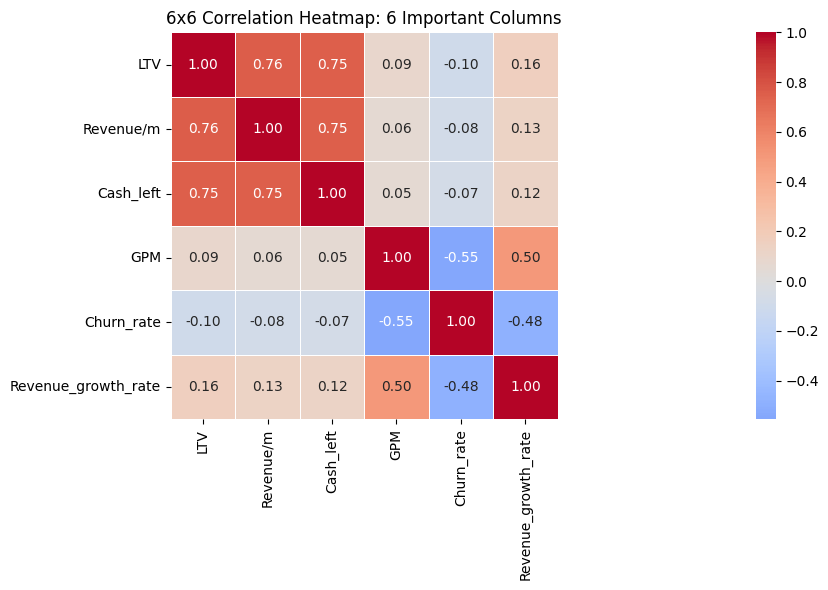

In [42]:
imp8 = ['LTV($/customer)', 'Monthly_Revenue($/month)', 'Cash_Available($)',
        'Gross_Profit_Margin(%)', 'Customer_Churn_Rate(%)', 'Revenue_Growth_Rate(%)']

# Compute correlation matrix
corr_matrix = df[imp8].corr()

# Shorter labels for readability
labels = ['LTV', 'Revenue/m', 'Cash_left', 'GPM', 'Churn_rate', 'Revenue_growth_rate']

# Plot heatmap
plt.figure(figsize=(40,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5,
            xticklabels=labels, yticklabels=labels)
plt.title('6x6 Correlation Heatmap: 6 Important Columns')
plt.tight_layout()
plt.show()

# Regplot
**It is mainly used to visualize the relationship between a numerical feature and the target variable and check whether a linear trend exists**

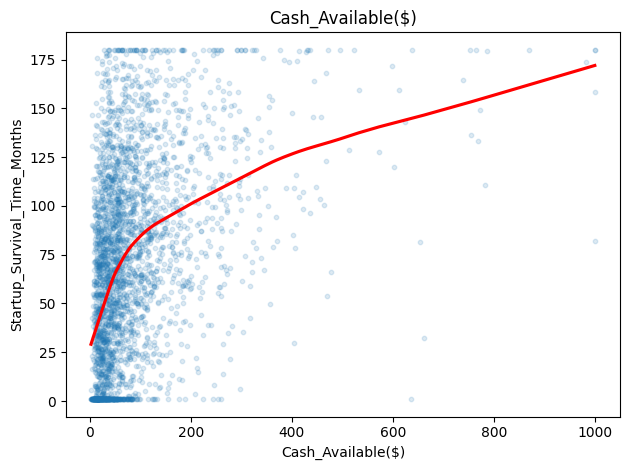

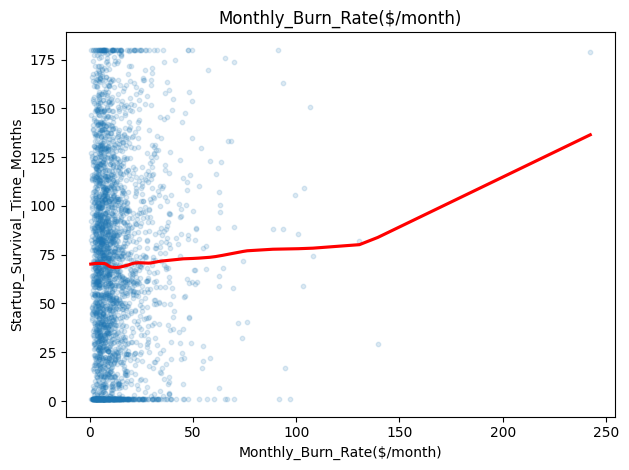

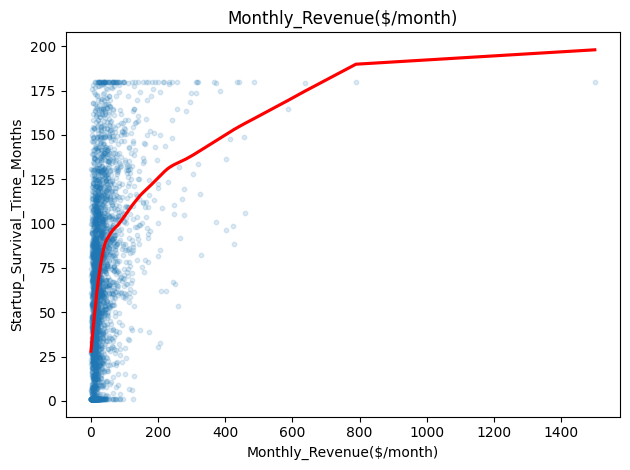

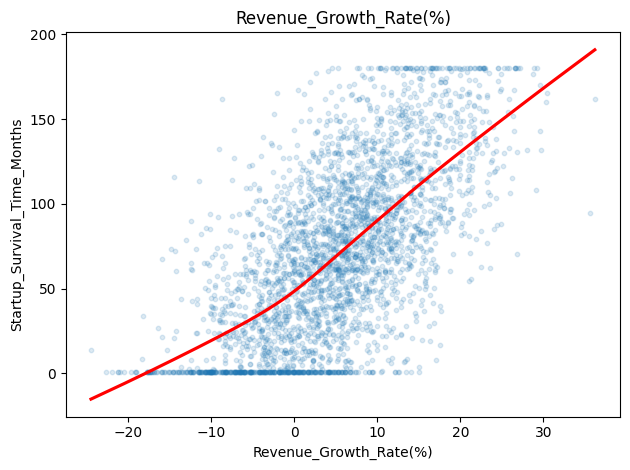

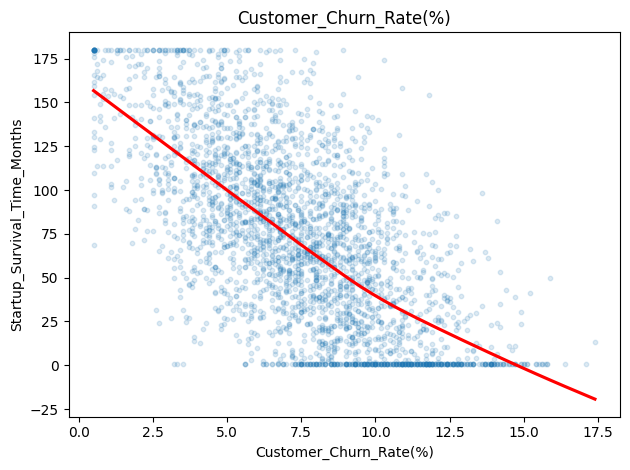

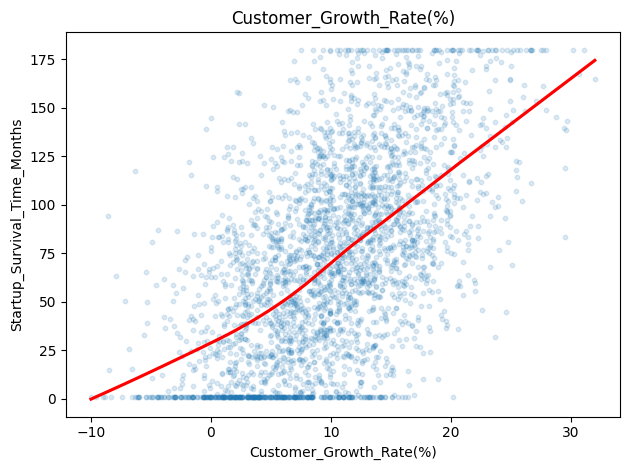

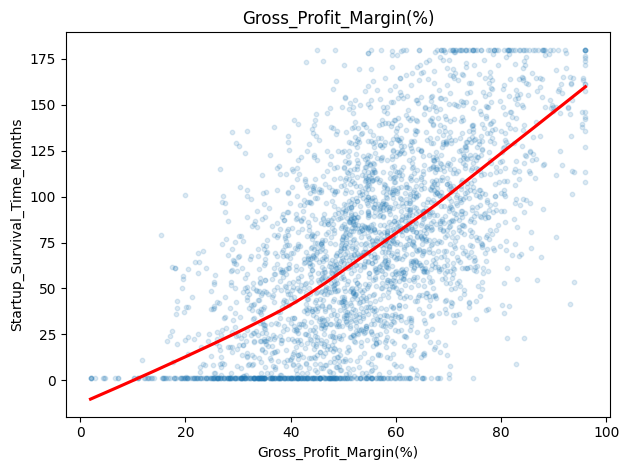

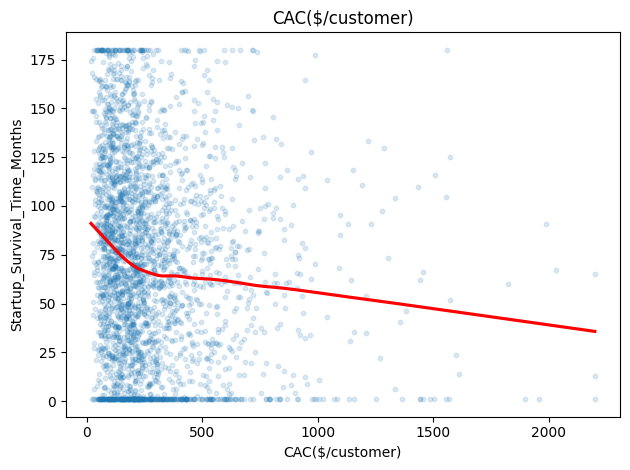

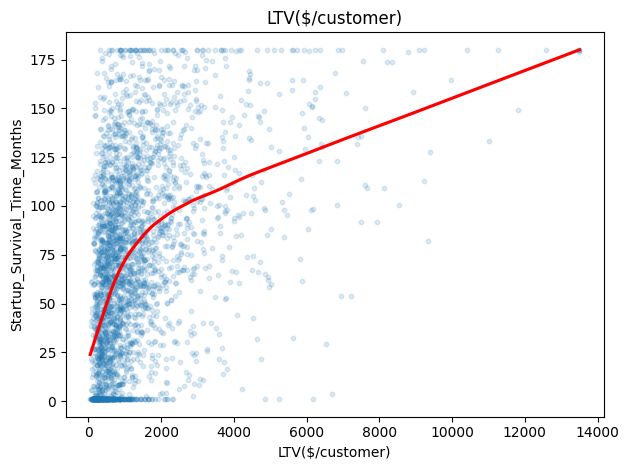

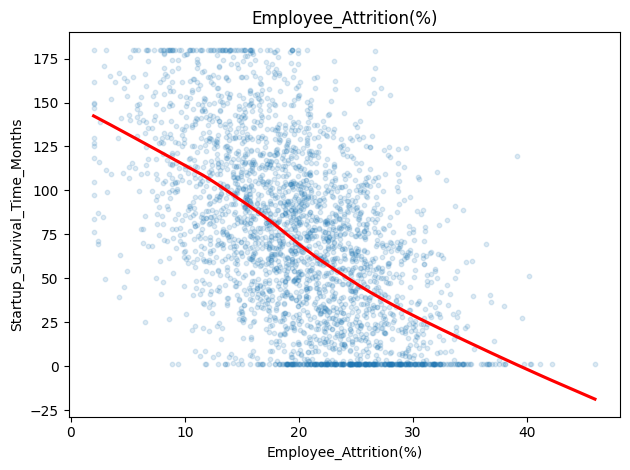

In [43]:
for col in num_col:
    sns.regplot(data=df, x=col, y='Startup_Survival_Time_Months',
                scatter_kws={'alpha': 0.15, 's': 10}, 
                line_kws={'color': 'red'}, lowess=True)
    plt.title(col)
    plt.tight_layout()
    plt.show()

# Histplot
**Done to check the data distribution of each column and also the skewness**

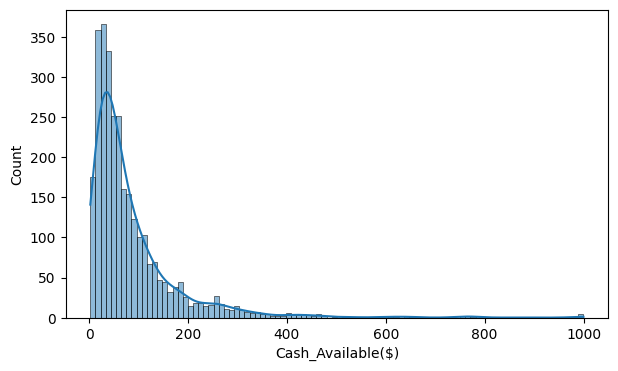

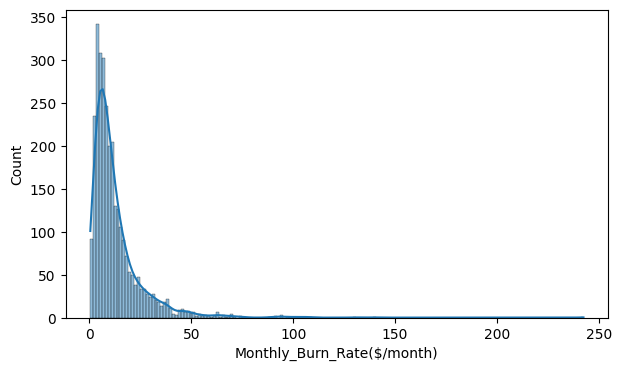

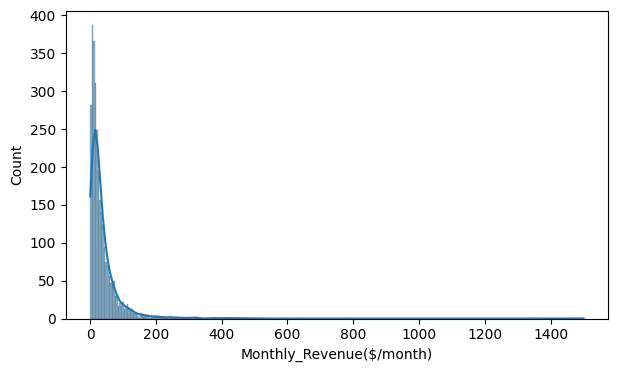

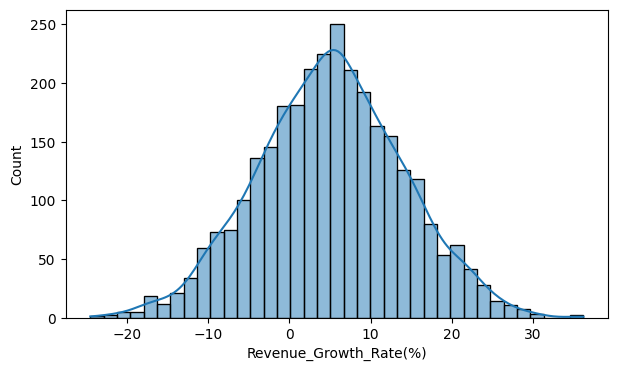

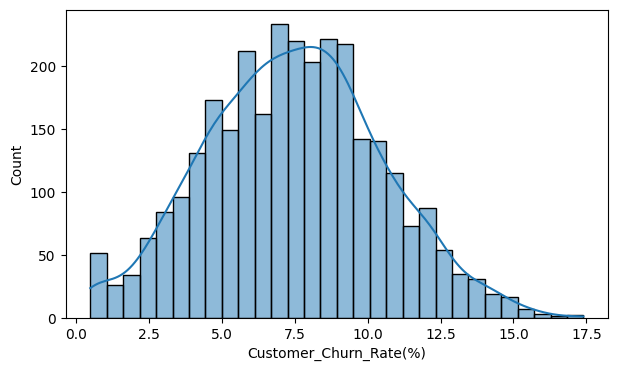

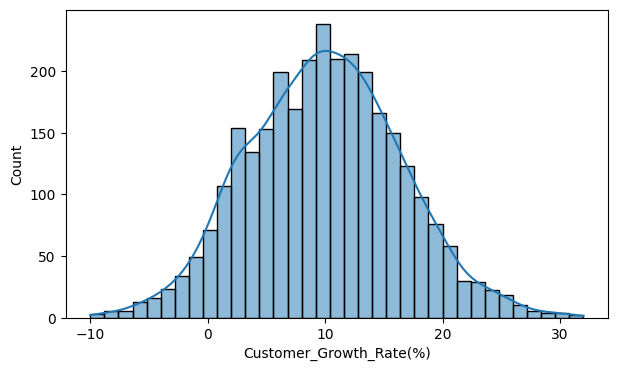

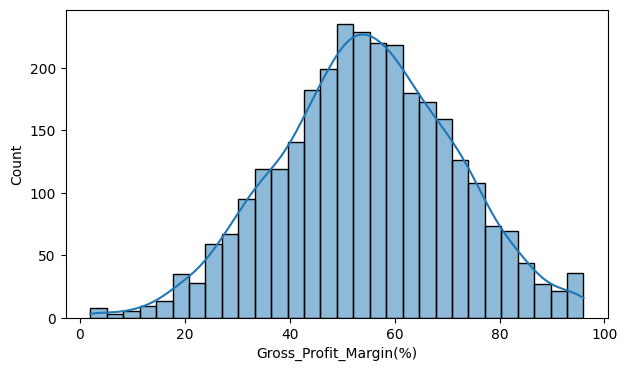

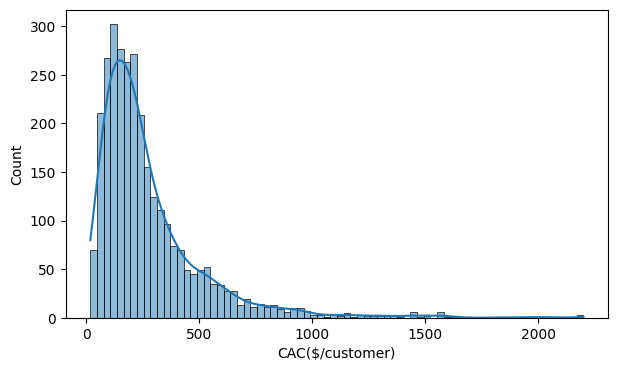

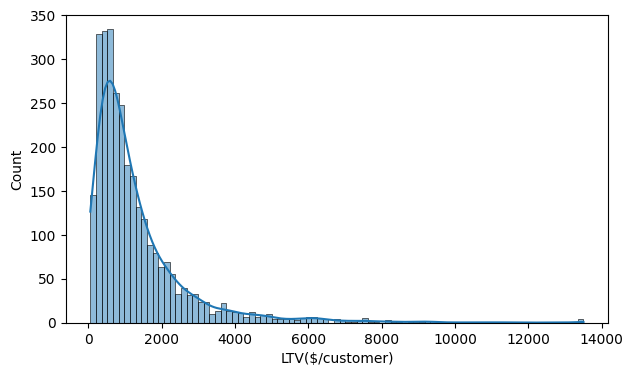

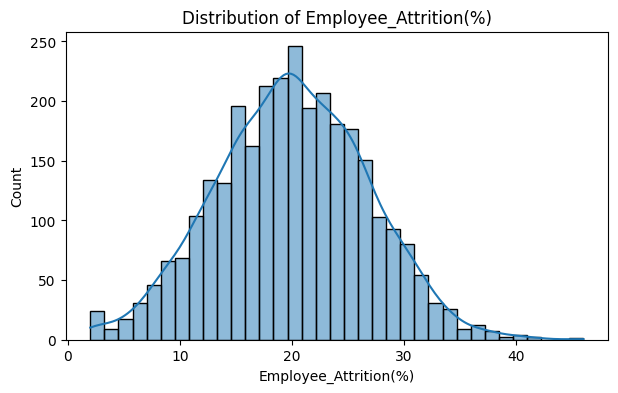

In [44]:
for col in num_col:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col],kde=True)

plt.title(f"Distribution of {col}")
plt.show()

# Boxplot
**Used to check the outliers in each feature**

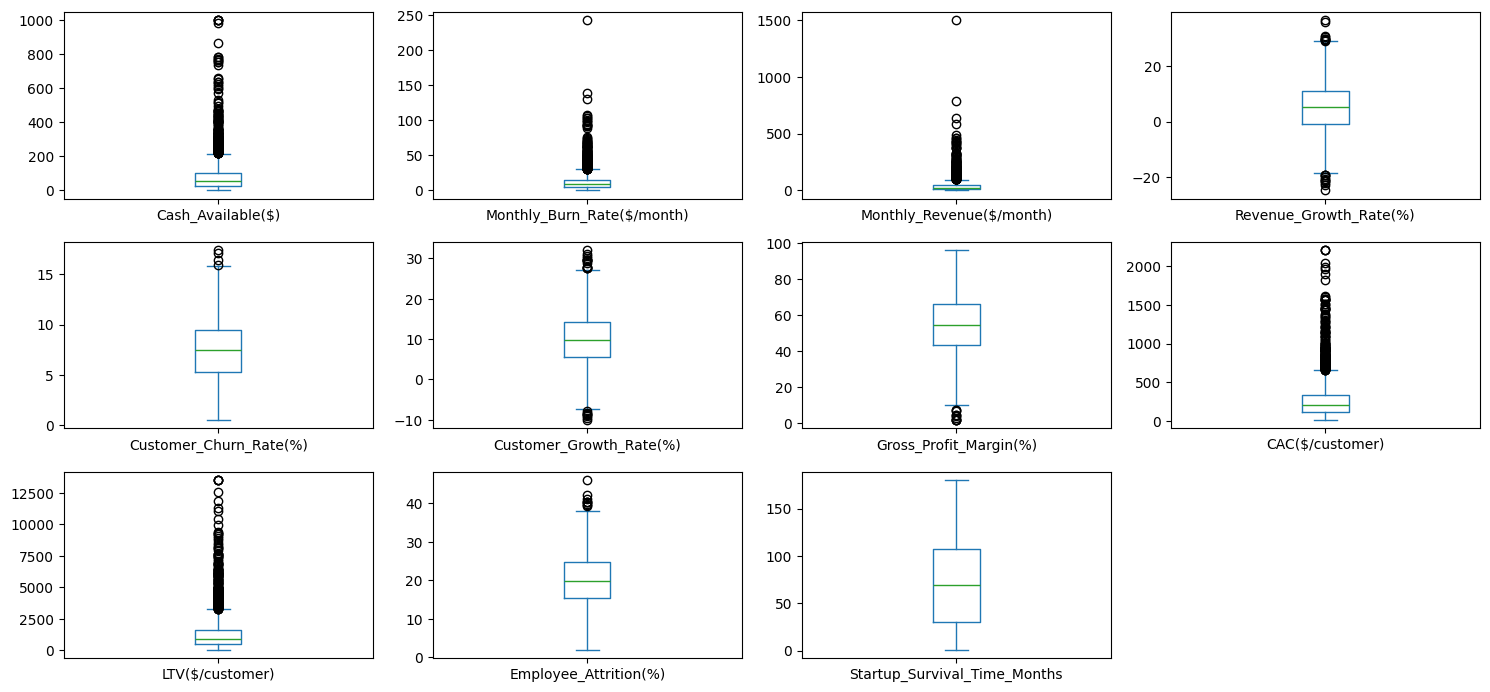

In [45]:
num_col = df.select_dtypes(include='number').columns
df[num_col].plot(kind='box', subplots=True, layout=(3,4), figsize=(15,7))
plt.tight_layout()
plt.show()

**Calculating the no of outliers in each column**

In [46]:
outlier_counts = {}

for col in num_col:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    outlier_counts[col] = len(outliers)

print(outlier_counts)

{'Cash_Available($)': 231, 'Monthly_Burn_Rate($/month)': 230, 'Monthly_Revenue($/month)': 245, 'Revenue_Growth_Rate(%)': 21, 'Customer_Churn_Rate(%)': 4, 'Customer_Growth_Rate(%)': 23, 'Gross_Profit_Margin(%)': 11, 'CAC($/customer)': 185, 'LTV($/customer)': 215, 'Employee_Attrition(%)': 9, 'Startup_Survival_Time_Months': 0}


# Scatterplot
**A scatter plot is used to visually explore the relationship, pattern, and possible outliers between an input feature and the target variable**

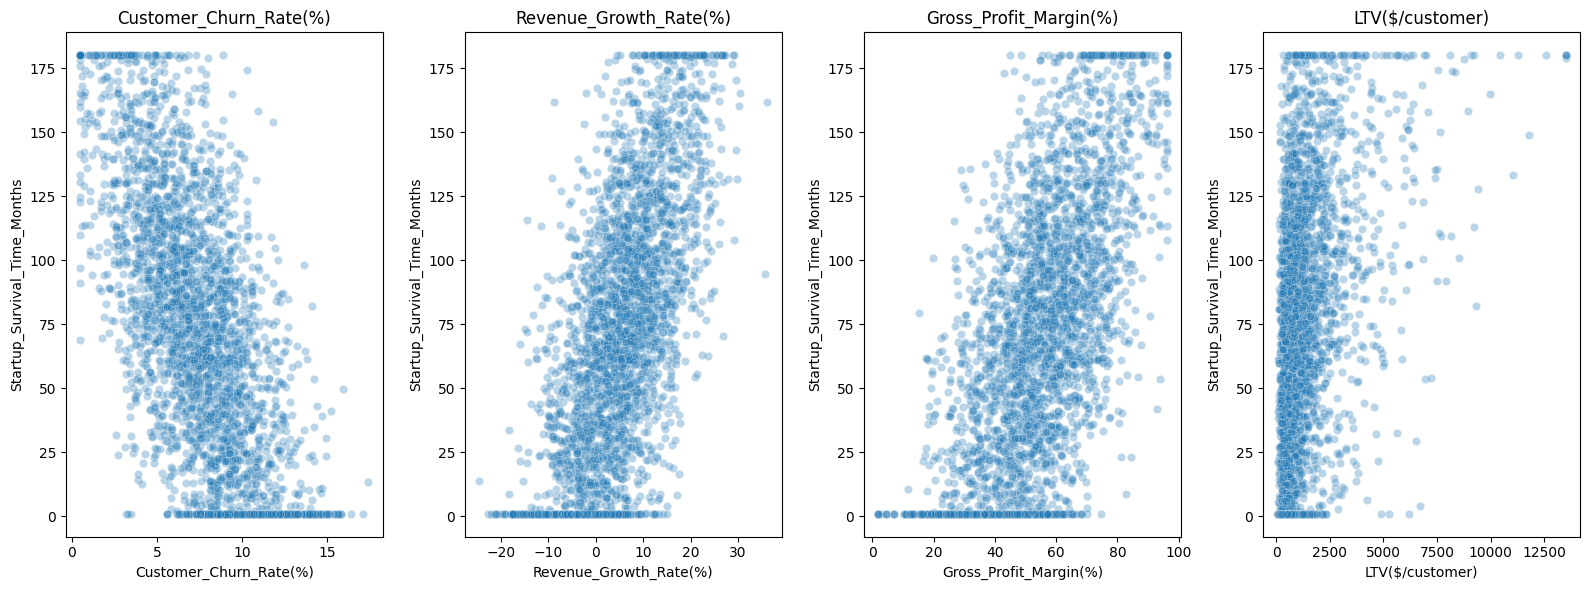

In [47]:
top4 = ['Customer_Churn_Rate(%)', 'Revenue_Growth_Rate(%)', 'Gross_Profit_Margin(%)', 'LTV($/customer)']

fig, axes = plt.subplots(1, 4, figsize=(16, 6))

for ax, col in zip(axes, top4):
    sns.scatterplot(data=df, x=col, y='Startup_Survival_Time_Months', alpha=0.3, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# Piechart
**A pie chart is used to visualize the percentage distribution of observations across different categories in a categorical feature**

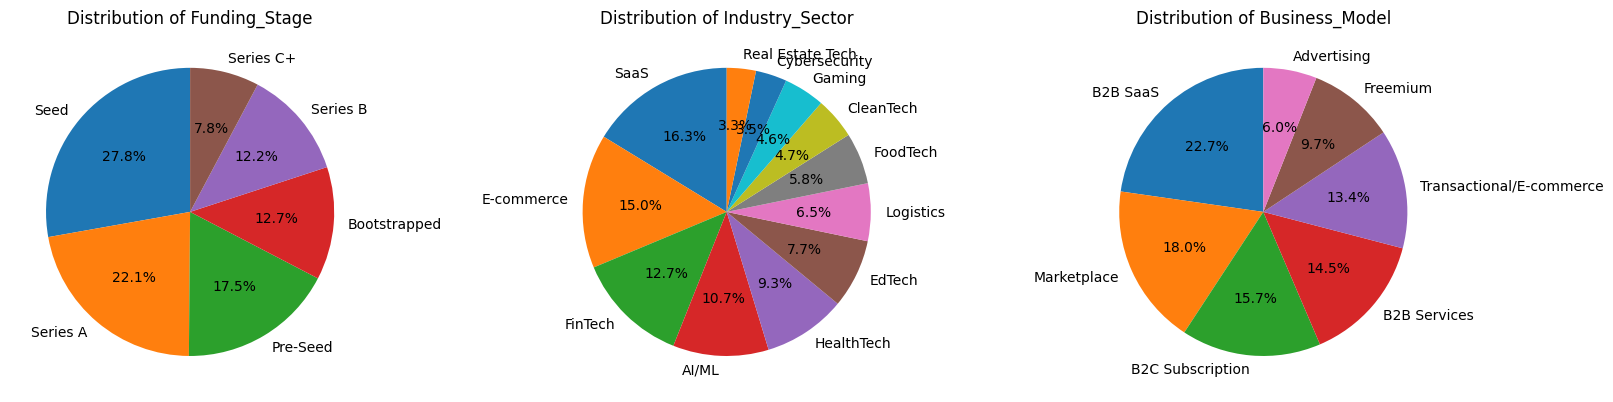

In [48]:

fig, axes = plt.subplots(2, 4, figsize=(20, 18))

# Convert 2D axes array into a 1D array
axes = axes.flatten()

for ax, col in zip(axes, cat_col):

    # Count original category names
    value_counts = df[col].value_counts()

    ax.pie(
        value_counts.values,
        labels=value_counts.index,
        autopct='%1.1f%%',
        startangle=90
    )

    ax.set_title(f'Distribution of {col}')

# Remove unused subplots if any
for ax in axes[len(cat_col):]:
    ax.remove()

plt.tight_layout()
plt.show()

# Feature/Target Separation
Splitting the dataset into input features (X) and the target variable (y-Startup_Survival_Time_Months).

In [49]:
X = df.drop(columns=['Startup_Survival_Time_Months'])

y = df['Startup_Survival_Time_Months']

# Train-Test Split
Splitting the dataset into training (80%) and testing (20%) sets, using stratified sampling to preserve class distribution in both sets.

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Preprocessing Pipeline

Preprocessing was implemented using a single ColumnTransformer, combining three parallel branches: Log transformer , StandardScaler & One Hot Encoding.

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

log_columns = [
    'Cash_Available($)',
    'Monthly_Burn_Rate($/month)',
    'Monthly_Revenue($/month)',
    'CAC($/customer)',
    'LTV($/customer)'
]
other_numerical = [
    'Revenue_Growth_Rate(%)',
    'Customer_Churn_Rate(%)',
    'Customer_Growth_Rate(%)',
    'Gross_Profit_Margin(%)',
    'Employee_Attrition(%)'
]
log_pipeline = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scale', StandardScaler())
])
num_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first',handle_unknown='ignore', sparse_output=False), cat_col),
        ('log_scale', log_pipeline, log_columns),
        ('scale', num_pipeline, other_numerical)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

# Multiple Linear Regression - with Evaluation Metrics

Multiple Linear Regression is used as a baseline regression model.

The model estimates the relationship between multiple input features and Startup Survival Time by fitting a linear relationship between the predictors and the target variable.


In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---- Linear Regression ----
lr = LinearRegression()
lr.fit(X_train_processed, y_train)

y_pred_lr = lr.predict(X_test_processed)

mse_lr=mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

n = X_test_processed.shape[0]   # number of test samples
p = X_test_processed.shape[1]   # number of features (predictors)
adj_r2_lr = 1 - (1 - r2_lr) * (n - 1) / (n - p - 1)

print("Linear Regression Results")
print("RMSE:", rmse_lr)
print("MAE :", mae_lr)
print("R2  :", r2_lr)
print("Adjusted R2:", adj_r2_lr)

Linear Regression Results
RMSE: 18.56705554593589
MAE : 14.513724469457545
R2  : 0.8614464040099232
Adjusted R2: 0.853626800708896


# Ridge Regression - with Evaluation Metrics

Ridge Regression applies L2 regularization to the regression model.

The regularization penalty reduces the magnitude of regression coefficients and can help improve model stability when multicollinearity exists among the input features.


In [53]:
from sklearn.linear_model import Ridge

# ---- Ridge Regression (L2) ----
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_processed, y_train)

y_pred_ridge = ridge.predict(X_test_processed)

mse_ridge=mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
adj_r2_ridge = 1 - (1 - r2_ridge) * (n - 1) / (n - p - 1)

print("Ridge Regression (L2) Results")
print("RMSE       :", rmse_ridge)
print("MAE        :", mae_ridge)
print("R2         :", r2_ridge)
print("Adjusted R2:", adj_r2_ridge)

Ridge Regression (L2) Results
RMSE       : 18.569503603586334
MAE        : 14.52053149755493
R2         : 0.8614098651467031
Adjusted R2: 0.8535881996876106


# Lasso Regression - with Evaluation Metrics

Lasso Regression applies L1 regularization.

In addition to reducing coefficient magnitudes, Lasso can shrink some coefficients completely to zero.

This property can perform implicit feature selection by reducing the influence of less important features.


In [54]:
from sklearn.linear_model import Lasso

# ---- Lasso Regression (L1) ----
lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(X_train_processed, y_train)

y_pred_lasso = lasso.predict(X_test_processed)

mse_lasso=mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
adj_r2_lasso = 1 - (1 - r2_lasso) * (n - 1) / (n - p - 1)

print("Lasso Regression (L1) Results")
print("RMSE       :", rmse_lasso)
print("MAE        :", mae_lasso)
print("R2         :", r2_lasso)
print("Adjusted R2:", adj_r2_lasso)

Lasso Regression (L1) Results
RMSE       : 20.137696901166862
MAE        : 16.093447940064195
R2         : 0.8370136146475695
Adjusted R2: 0.8278150884901131


# Elastic Net Regression - with Evaluation Metrics

Elastic Net Regression combines both L1 and L2 regularization.

It provides a balance between the feature-selection behavior of Lasso Regression and the coefficient-stabilization behavior of Ridge Regression.

This makes Elastic Net useful when the dataset contains correlated features.


In [55]:
from sklearn.linear_model import ElasticNet

# ---- ElasticNet Regression ----
elastic = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
elastic.fit(X_train_processed, y_train)

y_pred_elastic = elastic.predict(X_test_processed)

mse_elastic=mean_squared_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)
adj_r2_elastic = 1 - (1 - r2_elastic) * (n - 1) / (n - p - 1)

print("ElasticNet Regression Results")
print("RMSE       :", rmse_elastic)
print("MAE        :", mae_elastic)
print("R2         :", r2_elastic)
print("Adjusted R2:", adj_r2_elastic)

ElasticNet Regression Results
RMSE       : 22.176314899047956
MAE        : 17.940265319587102
R2         : 0.8023437787995567
Adjusted R2: 0.7911885776030589


# Overfitting/Underfitting check
**For Linear Regression below- Since Both training and testing values are very close to each other , no overfitting or underfitting patterns are found here**

In [56]:
# Train predictions
y_train_pred_lr = lr.predict(X_train_processed)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lr)) 
train_r2 = r2_score(y_train, y_train_pred_lr)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
test_r2 = r2_score(y_test, y_pred_lr)

print(f"Train RMSE: {train_rmse:.3f}   |   Test RMSE: {test_rmse:.3f}")
print(f"Train R2  : {train_r2:.4f}   |   Test R2  : {test_r2:.4f}")

gap_rmse = test_rmse - train_rmse
gap_r2 = train_r2 - test_r2
print(f"\nRMSE gap: {gap_rmse:.3f}")
print(f"R2 gap  : {gap_r2:.4f}")

Train RMSE: 17.413   |   Test RMSE: 18.567
Train R2  : 0.8801   |   Test R2  : 0.8614

RMSE gap: 1.154
R2 gap  : 0.0186


**For ridge below - Since Both training and testing values are very close to each other , no overfitting or underfitting patterns are found here**

In [57]:
y_train_pred_ridge = ridge.predict(X_train_processed)

train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)

# Test predictions (already have y_pred_ridge from earlier)
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
test_r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Train RMSE: {train_rmse_ridge:.3f}   |   Test RMSE: {test_rmse_ridge:.3f}")
print(f"Ridge Train R2  : {train_r2_ridge:.4f}   |   Test R2  : {test_r2_ridge:.4f}")

gap_rmse_ridge = test_rmse_ridge - train_rmse_ridge
gap_r2_ridge = train_r2_ridge - test_r2_ridge
print(f"\nRidge RMSE gap: {gap_rmse_ridge:.3f}")
print(f"Ridge R2 gap  : {gap_r2_ridge:.4f}")

Ridge Train RMSE: 17.413   |   Test RMSE: 18.570
Ridge Train R2  : 0.8801   |   Test R2  : 0.8614

Ridge RMSE gap: 1.157
Ridge R2 gap  : 0.0187


# Residual Analysis - for Multiple Linear Regression

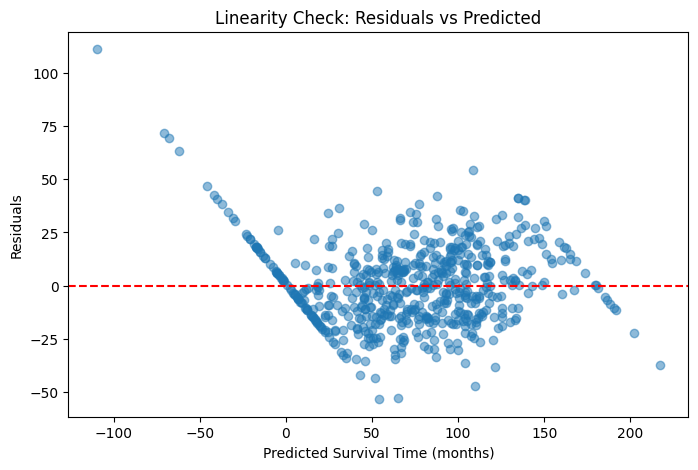

In [58]:
import matplotlib.pyplot as plt
residuals = y_test - y_pred_lr

plt.figure(figsize=(8,5))
plt.scatter(y_pred_lr, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Survival Time (months)')
plt.ylabel('Residuals')
plt.title('Linearity Check: Residuals vs Predicted')
plt.show()

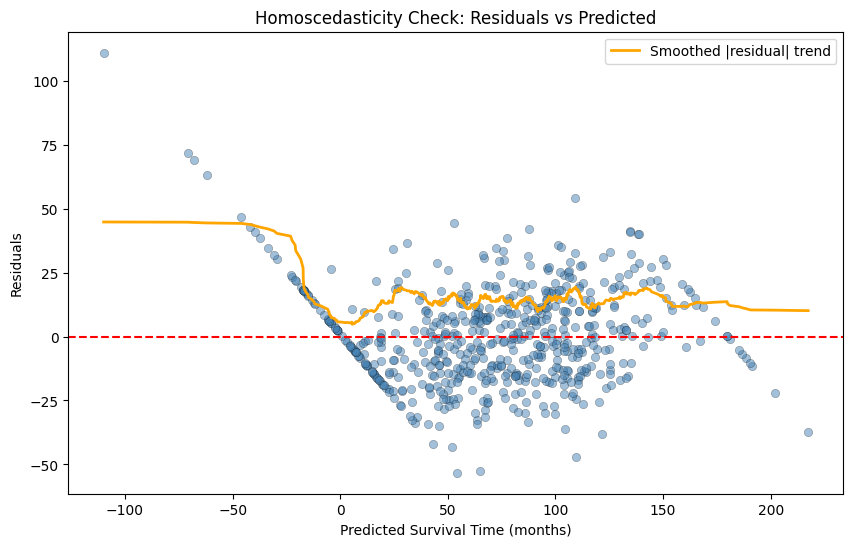

In [59]:
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test - y_pred_lr

plt.figure(figsize=(10,6))
plt.scatter(y_pred_lr, residuals, alpha=0.5, color='steelblue', edgecolor='k', linewidth=0.3)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

# Optional: add a smoothed trend line to help spot funnel shape
from scipy.ndimage import uniform_filter1d
sorted_idx = np.argsort(y_pred_lr)
sorted_pred = np.array(y_pred_lr)[sorted_idx]
sorted_resid_abs = np.abs(np.array(residuals))[sorted_idx]
smoothed = uniform_filter1d(sorted_resid_abs, size=30)
plt.plot(sorted_pred, smoothed, color='orange', linewidth=2, label='Smoothed |residual| trend')

plt.xlabel('Predicted Survival Time (months)')
plt.ylabel('Residuals')
plt.title('Homoscedasticity Check: Residuals vs Predicted')
plt.legend()
plt.show()

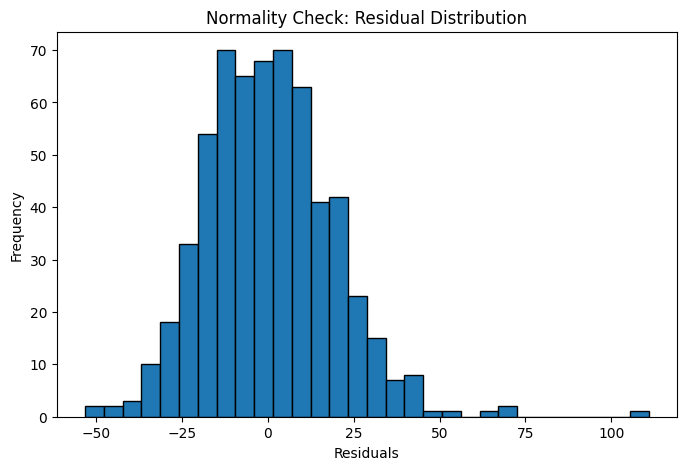

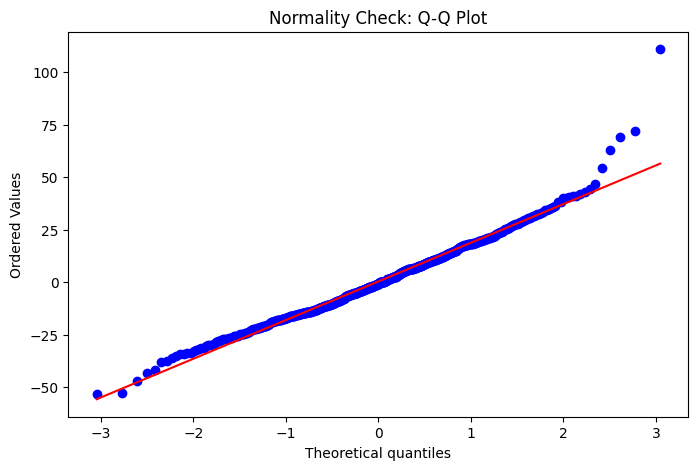

In [60]:
import scipy.stats as stats

# Histogram
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Normality Check: Residual Distribution')
plt.show()

# Q-Q Plot
plt.figure(figsize=(8,5))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normality Check: Q-Q Plot')
plt.show()

# Residual Analysis - for Ridge Regression

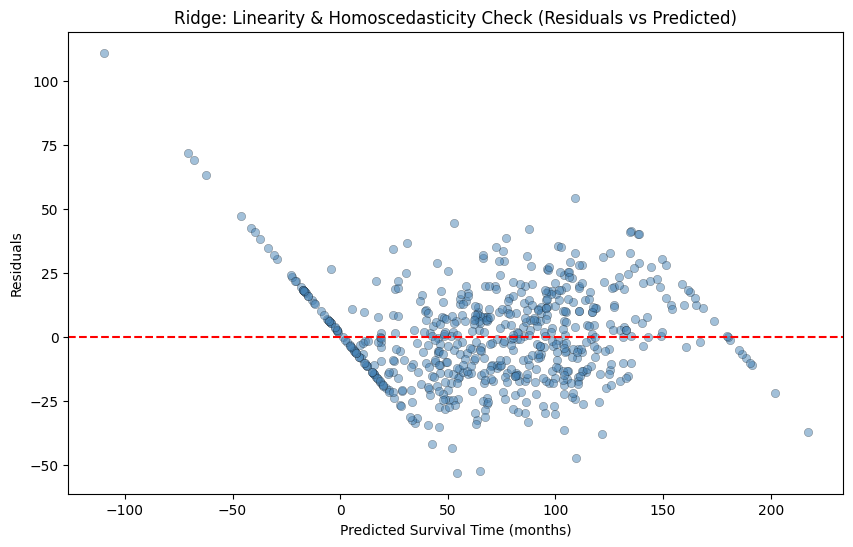

In [61]:
residuals_ridge = y_test - y_pred_ridge

plt.figure(figsize=(10,6))
plt.scatter(y_pred_ridge, residuals_ridge, alpha=0.5, color='steelblue', edgecolor='k', linewidth=0.3)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Survival Time (months)')
plt.ylabel('Residuals')
plt.title('Ridge: Linearity & Homoscedasticity Check (Residuals vs Predicted)')
plt.show()

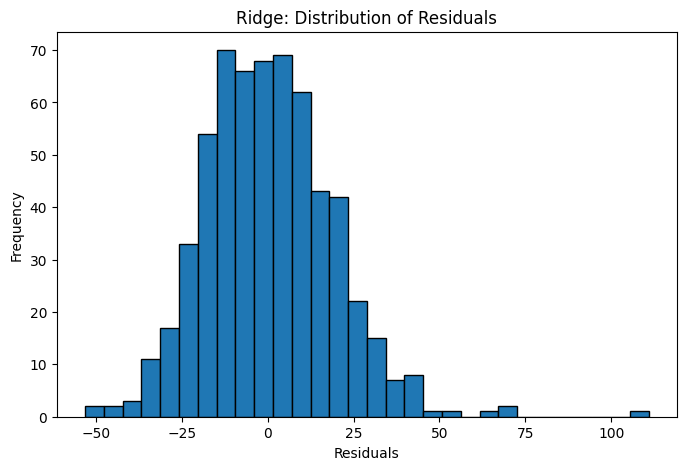

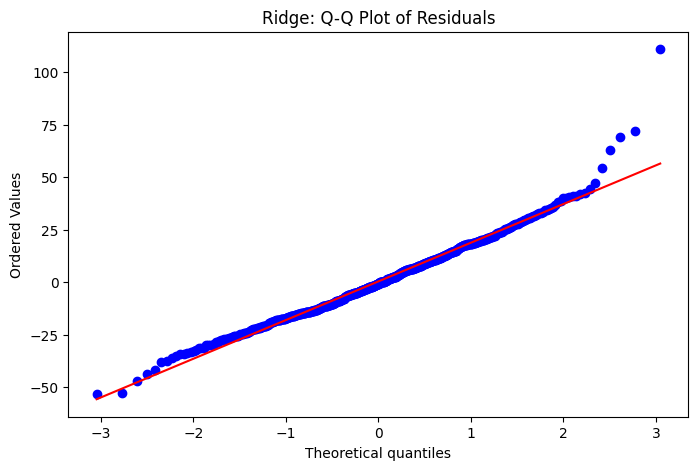

In [62]:
import scipy.stats as stats

# Histogram
plt.figure(figsize=(8,5))
plt.hist(residuals_ridge, bins=30, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Ridge: Distribution of Residuals')
plt.show()

# Q-Q Plot
plt.figure(figsize=(8,5))
stats.probplot(residuals_ridge, dist="norm", plot=plt)
plt.title('Ridge: Q-Q Plot of Residuals')
plt.show()

# Model comparison bar chart

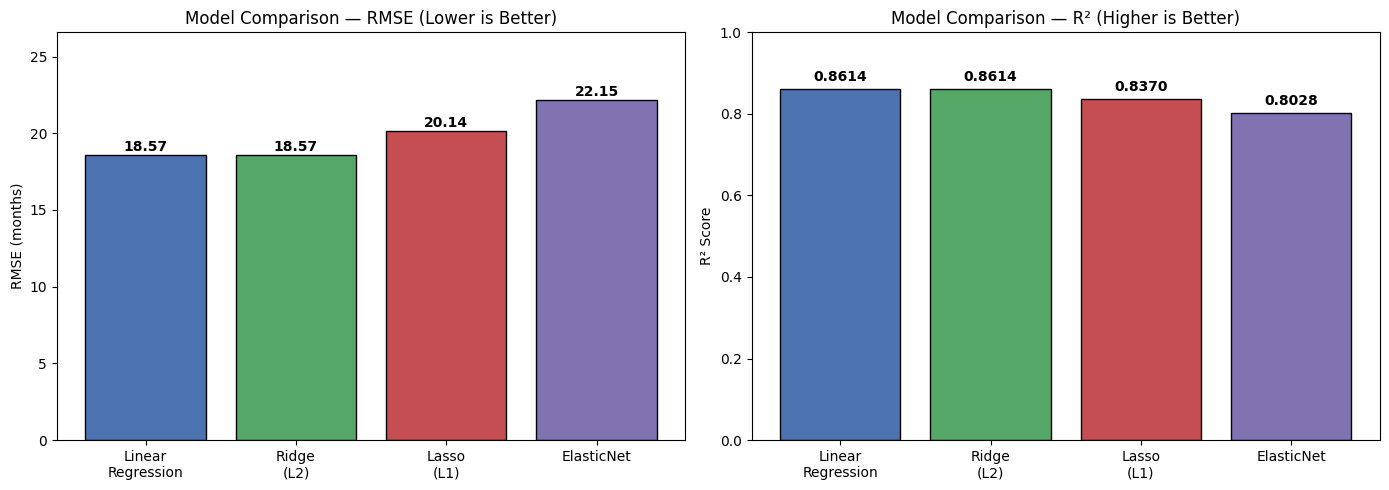

In [63]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Linear\nRegression', 'Ridge\n(L2)', 'Lasso\n(L1)', 'ElasticNet']
rmse_values = [18.567, 18.570, 20.138, 22.152]
r2_values = [0.8614, 0.8614, 0.8370, 0.8028]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- RMSE bar chart ----
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars1 = axes[0].bar(models, rmse_values, color=colors, edgecolor='black')
axes[0].set_ylabel('RMSE (months)')
axes[0].set_title('Model Comparison — RMSE (Lower is Better)')
axes[0].set_ylim(0, max(rmse_values) * 1.2)

for bar, val in zip(bars1, rmse_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}', ha='center', fontweight='bold')

# ---- R² bar chart ----
bars2 = axes[1].bar(models, r2_values, color=colors, edgecolor='black')
axes[1].set_ylabel('R² Score')
axes[1].set_title('Model Comparison — R² (Higher is Better)')
axes[1].set_ylim(0, 1.0)

for bar, val in zip(bars2, r2_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Final Model Selection

**Multiple Linear Regression is selected as the final model due to its strong performance, simplicity, and interpretability.**
Both models are also giving similar output for the residual analysis also. Although Multiple Linear Regression does not include built-in regularization techniques to control overfitting, it showed no significant signs of overfitting in this dataset, as the training and testing performance were similar. Ridge Regression includes L2 regularization to reduce overfitting and handle multicollinearity; however, it did not provide a significant improvement over Multiple Linear Regression. Therefore, Multiple Linear Regression was selected as the final model due to its strong performance, simplicity, and interpretability.

# Feature Coefficient Analysis
**This code extracts the final processed feature names and their Linear Regression coefficients, ranks them by coefficient magnitude, and helps to understand which features have the strongest positive or negative linear relationship with predicted startup survival time.**

In [64]:
feature_names = preprocessor.get_feature_names_out() 

coef_df = pd.DataFrame({
    'Feature': feature_names, 
    'Coefficient': lr.coef_
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs() 
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)  

print(coef_df.to_string(index=False))
print("Intercept:", lr.intercept_) 

                                Feature  Coefficient  Abs_Coefficient
                Funding_Stage_Series C+    31.212912        31.212912
                 Funding_Stage_Series B    20.149972        20.149972
                 Customer_Churn_Rate(%)   -12.988900        12.988900
                 Revenue_Growth_Rate(%)    11.623561        11.623561
                 Funding_Stage_Series A    11.548348        11.548348
               Monthly_Revenue($/month)    11.008459        11.008459
                Business_Model_B2B SaaS     9.408206         9.408206
                 Funding_Stage_Pre-Seed    -8.734259         8.734259
                  Employee_Attrition(%)    -8.461802         8.461802
                      Cash_Available($)     8.182769         8.182769
               Industry_Sector_FoodTech    -7.893649         7.893649
            Business_Model_B2B Services     7.411419         7.411419
                 Gross_Profit_Margin(%)     7.057431         7.057431
                 Ind

# Predicting Startup Survival Time for New Input Data
**A new input data is fed into multiple linear regression model to check the output**

In [65]:
import pandas as pd

new_data = pd.DataFrame({
    'Funding_Stage': ['Series A'],              
    'Industry_Sector': ['FinTech'],
    'Business_Model': ['B2B SaaS'],
    'Cash_Available($)': [247],
    'Monthly_Burn_Rate($/month)': [35],
    'Monthly_Revenue($/month)': [4000], 
    'CAC($/customer)': [26],
    'LTV($/customer)': [25],
    'Revenue_Growth_Rate(%)': [8.5],
    'Customer_Churn_Rate(%)': [10],
    'Customer_Growth_Rate(%)': [10],
    'Gross_Profit_Margin(%)': [1],
    'Employee_Attrition(%)': [17]
})
new_data_processed = preprocessor.transform(new_data)
prediction = lr.predict(new_data_processed)[0]
prediction = max(prediction, 1)   # survival time can't be negative or zero

print(f"Predicted Startup Survival Time: {prediction:.1f} months")

Predicted Startup Survival Time: 110.3 months


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Conclusion
This study compared four linear regression approaches — OLS, Ridge, Lasso, and ElasticNet — for predicting startup survival time. Linear Regression and Ridge performed nearly identically (RMSE ~18.57, R² ~0.861), while Lasso and ElasticNet underperformed, likely due to over-penalization at the default alpha rather than any real advantage of regularization. Diagnostic checks confirmed the dataset has no meaningful multicollinearity (VIF ≤ 5) and no overfitting (small train-test gap), explaining why regularization added no measurable benefit here. Residual analysis found a localized violation of linearity/homoscedasticity, traced to a small subset of predictions that extrapolated below zero — an impossible value for survival time — rather than a fundamental flaw in the model. Linear Regression is selected as the final model for its unbiased, directly interpretable coefficients and lack of hyperparameter dependence, with Ridge's equivalent performance serving as confirmation that regularization wasn't necessary for this dataset.